# 01 - Exploracion de Datos Historicos en Supabase

Este notebook conecta con Supabase para verificar los datos historicos del sensor BME680.

## 1. Instalacion de dependencias

In [1]:
import sys
!{sys.executable} -m pip install -q supabase pandas python-dotenv

## 2. Configuracion de conexion

In [2]:
from supabase import create_client
import pandas as pd
from dotenv import load_dotenv
import os

load_dotenv()

SUPABASE_URL = os.getenv("SUPABASE_URL")
SUPABASE_KEY = os.getenv("SUPABASE_KEY")

supabase = create_client(SUPABASE_URL, SUPABASE_KEY)
print("Conexion a Supabase establecida")
print(f"URL: {SUPABASE_URL}")

Conexion a Supabase establecida
URL: https://ffwjdoguzaqpafuwaeam.supabase.co


## 3. Verificacion de estructura de tabla

In [3]:
response = supabase.table("grupo1_air_quality").select("*").limit(1).execute()

if response.data:
    print("Columnas disponibles:")
    for key in response.data[0].keys():
        print(f"  - {key}")
else:
    print("No se encontraron datos en la tabla")

Columnas disponibles:
  - id
  - estacion
  - temperatura
  - humedad
  - presion
  - altura
  - gas
  - iaq
  - eco2
  - voc
  - calidad_aire
  - created_at


## 4. Carga de datos historicos

In [4]:
response = supabase.table("grupo1_air_quality").select("*").order("created_at", desc=True).limit(100).execute()

df = pd.DataFrame(response.data)
print(f"Total registros cargados: {len(df)}")
df.head(10)

Total registros cargados: 100


,id,estacion,temperatura,humedad,presion,altura,gas,iaq,eco2,voc,calidad_aire,created_at
0,5294,grupo1,10.22712,36.36262,647.40,3622.350,28437,0.0,400.0,0.5,Excelente,2026-06-27T21:12:11.696235-05:00
1,5293,grupo1,10.23125,36.30555,647.39,3622.470,27777,0.0,400.0,0.5,Excelente,2026-06-27T21:11:11.084558-05:00
2,5292,grupo1,10.23251,36.27122,647.38,3622.590,27025,0.0,400.0,0.5,Excelente,2026-06-27T21:10:11.196434-05:00
3,5291,grupo1,10.22966,36.23079,647.38,3622.590,26479,0.0,400.0,0.5,Excelente,2026-06-27T21:09:11.138449-05:00
4,5290,grupo1,10.23853,36.17419,647.37,3622.710,25652,0.0,400.0,0.5,Excelente,2026-06-27T21:08:11.460419-05:00
5,5289,grupo1,10.23853,36.11684,647.36,3622.830,24950,0.0,400.0,0.5,Excelente,2026-06-27T21:07:14.923297-05:00
6,5288,grupo1,10.23663,36.05935,647.33,3623.188,24048,0.0,400.0,0.5,Excelente,2026-06-27T21:06:11.056496-05:00
7,5287,grupo1,10.24741,36.05453,647.32,3623.308,23315,0.0,400.0,0.5,Excelente,2026-06-27T21:05:11.061517-05:00
8,5286,grupo1,10.25438,36.00929,647.29,3623.667,22417,0.0,400.0,0.5,Excelente,2026-06-27T21:04:11.872326-05:00
9,5285,grupo1,10.25343,35.94619,647.27,3623.906,21607,0.0,400.0,0.5,Excelente,2026-06-27T21:03:11.469682-05:00


## 5. Estadisticas descriptivas

In [5]:
numeric_possible = ["temperatura", "humedad", "presion", "iaq", "eco2", "voc", "VOC", "gas", "altura"]
numeric_cols = [c for c in numeric_possible if c in df.columns]

print(f"Columnas numericas encontradas: {numeric_cols}")
if numeric_cols:
    df[numeric_cols].describe()
else:
    print("No se encontraron columnas numericas conocidas")

Columnas numericas encontradas: ['temperatura', 'humedad', 'presion', 'iaq', 'eco2', 'voc', 'gas', 'altura']


## 6. Distribucion de calidad del aire

In [6]:
if "calidad_aire" in df.columns:
    print("Distribucion de calidad_aire:")
    print(df["calidad_aire"].value_counts())
else:
    print("Columna calidad_aire no encontrada")

Distribucion de calidad_aire:
calidad_aire
Ligeramente contaminada    74
Excelente                  26
Name: count, dtype: int64


## 7. Rango temporal de los datos

In [7]:
if "created_at" in df.columns:
    df["created_at"] = pd.to_datetime(df["created_at"])
    print(f"Primer registro: {df['created_at'].min()}")
    print(f"Ultimo registro: {df['created_at'].max()}")
    print(f"Rango: {df['created_at'].max() - df['created_at'].min()}")

Primer registro: 2026-06-23 22:04:52.990283-05:00
Ultimo registro: 2026-06-27 21:12:11.696235-05:00
Rango: 3 days 23:07:18.705952


## 8. Visualizacion rapida de temperatura

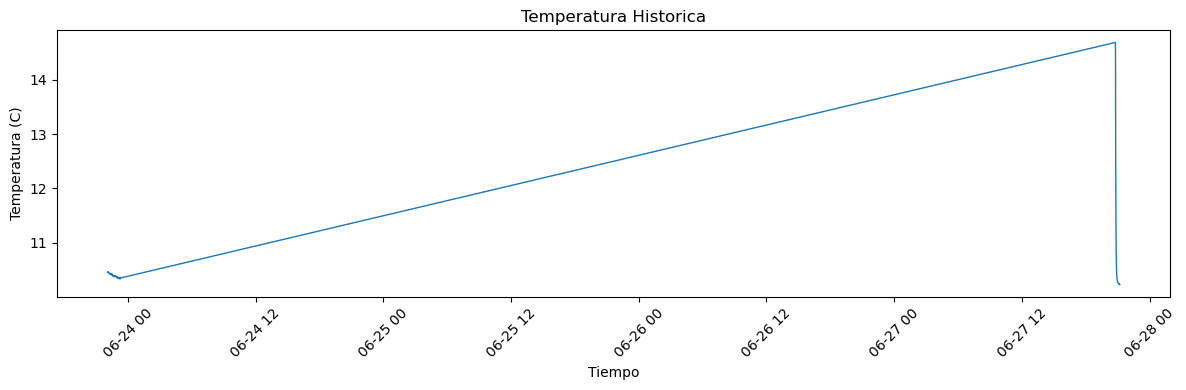

In [8]:
import matplotlib.pyplot as plt

if "created_at" in df.columns and "temperatura" in df.columns:
    df_sorted = df.sort_values("created_at")
    plt.figure(figsize=(12, 4))
    plt.plot(df_sorted["created_at"], df_sorted["temperatura"], linewidth=1)
    plt.title("Temperatura Historica")
    plt.xlabel("Tiempo")
    plt.ylabel("Temperatura (C)")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

## 9. Dato mas reciente (polling opcional)

Esta celda hace polling a Supabase para ver el ultimo registro. No es streaming real, solo verificacion puntual.

In [9]:
import time

print("Obteniendo dato mas reciente cada 5 segundos (Ctrl+C para detener)...\n")
try:
    for i in range(6):
        resp = supabase.table("grupo1_air_quality").select("*").order("created_at", desc=True).limit(1).execute()
        if resp.data:
            d = resp.data[0]
            print(f"[{i+1}] {d.get('created_at')} | Temp: {d.get('temperatura')}C | Hum: {d.get('humedad')}% | IAQ: {d.get('iaq')}")
        time.sleep(5)
except KeyboardInterrupt:
    print("\nPolling detenido")

Obteniendo dato mas reciente cada 5 segundos (Ctrl+C para detener)...

[1] 2026-06-27T21:12:11.696235-05:00 | Temp: 10.22712C | Hum: 36.36262% | IAQ: 0
[2] 2026-06-27T21:12:11.696235-05:00 | Temp: 10.22712C | Hum: 36.36262% | IAQ: 0
[3] 2026-06-27T21:12:11.696235-05:00 | Temp: 10.22712C | Hum: 36.36262% | IAQ: 0
[4] 2026-06-27T21:12:11.696235-05:00 | Temp: 10.22712C | Hum: 36.36262% | IAQ: 0
[5] 2026-06-27T21:12:11.696235-05:00 | Temp: 10.22712C | Hum: 36.36262% | IAQ: 0
[6] 2026-06-27T21:12:11.696235-05:00 | Temp: 10.22712C | Hum: 36.36262% | IAQ: 0
